<a href="https://colab.research.google.com/github/saigayatrikasireddi555-alt/Student-Performance-Prediction/blob/main/ai_minor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import files

uploaded = files.upload()

Saving True.csv to True.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [4]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

/tmp/ipykernel_2969/3936101748.py:2: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  true = pd.read_csv("True.csv")


In [5]:
print(fake.head())

print(true.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0   Donald Trump Sends Out Embarrassing New Yearâ...   
1   Drunk Bragging Trump Sta

In [6]:
fake["label"] = 0

true["label"] = 1

In [7]:
data = pd.concat([fake, true], ignore_index=True)

In [8]:
data = data.sample(frac=1, random_state=42)

data.reset_index(drop=True, inplace=True)

In [9]:
print(data.shape)

print(data.head())

print(data.info())

(46983, 173)
                                               title  \
0  WOW! BLACK DALLAS Police Sergeant Sues Obama, ...   
1  WATCH: REMEMBER When President Clinton Took Cr...   
2   Hannity Gets His A** Kicked By Newsweek For L...   
3  PELOSI GIGGLES NERVOUSLY: “After I Met Preside...   
4  The Las Vegas Mass Shooting – More to the Stor...   

                                                text    subject  \
0  Read the list of people and organizations this...   politics   
1  Bill Clinton was falsely confident in his plan...   politics   
2  Sean Hannity is definitely going to blow a gas...       News   
3  Nancy Pelosi said in an interview with Joy Rei...  left-news   
4  Shawn Helton 21st Century WireAlthough many ar...    US_News   

               date  label Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7  \
0         18-Sep-16      1        NaN        NaN        NaN        NaN   
1       Aug 9, 2017      0        NaN        NaN        NaN        NaN   
2   August 15, 2016      

In [10]:
X = data["text"]

y = data["label"]

In [11]:
vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
prediction = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.18165371927210813


In [16]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.17      0.17      0.17      4655
           1       0.19      0.19      0.19      4742

    accuracy                           0.18      9397
   macro avg       0.18      0.18      0.18      9397
weighted avg       0.18      0.18      0.18      9397



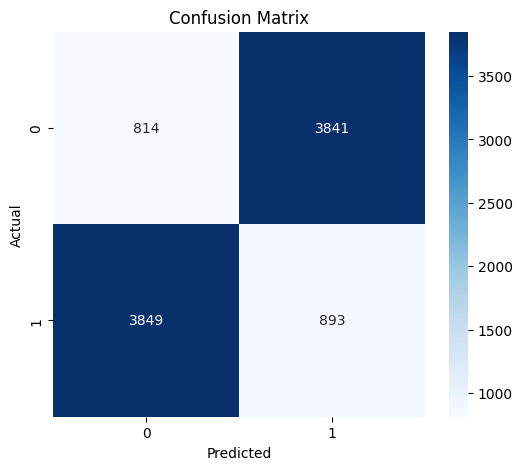

In [17]:
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
news = [
    "Scientists discover a new planet similar to Earth."
]

news_vector = vectorizer.transform(news)

result = model.predict(news_vector)

if result[0] == 1:
    print("Real News")
else:
    print("Fake News")

Real News


In [19]:
news = [
    "Aliens have landed on Earth and taken over the government."
]

news_vector = vectorizer.transform(news)

result = model.predict(news_vector)

if result[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News
